In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# DXSUM - Diagnosis at every visit
# PTDEMOG - Patient demographics
# MMSE - Cognitive test scores
# CDR - Clinical Dementia Rating scores
dx = pd.read_csv('../data/raw/DXSUM.csv')
demog = pd.read_csv('../data/raw/PTDEMOG.csv')
mmse = pd.read_csv('../data/raw/MMSE.csv')
cdr = pd.read_csv('../data/raw/CDR.csv')

print("DXSUM shape:", dx.shape)
print("PTDEMOG shape:", demog.shape)
print("MMSE shape:", mmse.shape)
print("CDR shape:", cdr.shape)

DXSUM shape: (15881, 42)
PTDEMOG shape: (6219, 85)
MMSE shape: (14599, 59)
CDR shape: (14617, 26)


In [20]:
# Look at diagnosis columns
print(dx.columns.tolist())

['ORIGPROT', 'COLPROT', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'DIAGNOSIS', 'DXNORM', 'DXNODEP', 'DXMCI', 'DXMDES', 'DXMPTR1', 'DXMPTR2', 'DXMPTR3', 'DXMPTR4', 'DXMPTR5', 'DXMPTR6', 'DXMDUE', 'DXMOTHET', 'DXDSEV', 'DXDDUE', 'DXAD', 'DXAPP', 'DXAPROB', 'DXAPOSS', 'DXPARK', 'DXPDES', 'DXPCOG', 'DXPATYP', 'DXDEP', 'DXOTHDEM', 'DXODES', 'DXCONFID', 'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'DD_CRF_VERSION_LABEL', 'LANGUAGE_CODE', 'HAS_QC_ERROR', 'update_stamp']


In [21]:
# Preview DXSUM
dx.head(10)

,ORIGPROT,COLPROT,PTID,RID,VISCODE,VISCODE2,EXAMDATE,DIAGNOSIS,DXNORM,DXNODEP,...,DXODES,DXCONFID,ID,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,HAS_QC_ERROR,update_stamp
0,ADNI1,ADNI1,011_S_0002,2,bl,bl,2005-09-29,CN,Yes,NaN,...,NaN,Highly Confident,2.0,107,2005-10-01,NaN,NaN,NaN,NaN,2005-10-01
1,ADNI1,ADNI1,011_S_0003,3,bl,bl,2005-09-30,Dementia,NaN,NaN,...,NaN,Moderately Confident,4.0,107,2005-10-01,NaN,NaN,NaN,NaN,2005-10-01
2,ADNI1,ADNI1,011_S_0005,5,bl,bl,2005-09-30,CN,Yes,NaN,...,NaN,Highly Confident,6.0,107,2005-10-01,NaN,NaN,NaN,NaN,2005-10-01
3,ADNI1,ADNI1,011_S_0008,8,bl,bl,2005-09-30,CN,Yes,NaN,...,NaN,Moderately Confident,8.0,107,2005-10-01,NaN,NaN,NaN,NaN,2005-10-01
4,ADNI1,ADNI1,022_S_0007,7,bl,bl,2005-10-06,Dementia,NaN,NaN,...,NaN,Highly Confident,10.0,10,2005-10-06,NaN,NaN,NaN,NaN,2005-10-06
5,ADNI1,ADNI1,100_S_0015,15,bl,bl,2005-10-18,CN,Yes,NaN,...,NaN,Highly Confident,12.0,4,2005-10-18,NaN,NaN,NaN,NaN,2005-10-18
6,ADNI1,ADNI1,023_S_0030,30,bl,bl,2005-10-20,MCI,NaN,NaN,...,NaN,Highly Confident,14.0,11,2005-10-20,NaN,NaN,NaN,NaN,2005-10-20
7,ADNI1,ADNI1,023_S_0031,31,bl,bl,2005-10-24,CN,Yes,NaN,...,NaN,Highly Confident,16.0,11,2005-10-24,NaN,NaN,NaN,NaN,2005-10-24
8,ADNI1,ADNI1,011_S_0016,16,bl,bl,2005-10-25,CN,Yes,NaN,...,NaN,Moderately Confident,18.0,107,2005-11-02,NaN,NaN,NaN,NaN,2005-11-02
9,ADNI1,ADNI1,011_S_0021,21,bl,bl,2005-11-01,CN,Yes,NaN,...,NaN,Highly Confident,20.0,107,2005-11-02,NaN,NaN,NaN,NaN,2005-11-02


In [22]:
# Check what DIAGNOSIS values look like
print(dx['DIAGNOSIS'].value_counts())
print("\nVisit codes:")
print(dx['VISCODE'].value_counts().head(20))

DIAGNOSIS
MCI         6565
CN          6275
Dementia    2996
Name: count, dtype: int64

Visit codes:
VISCODE
bl        1645
v01       1056
sc         966
v11        942
m06        897
4_sc       818
v21        815
v03        782
m12        739
v05        719
m24        645
4_bl       584
y2         564
4_init     507
y1         474
v31        465
m36        459
v41        444
init       407
v06        381
Name: count, dtype: int64


In [23]:
# Get baseline diagnoses (bl and sc are both baseline visits)
baseline = dx[dx['VISCODE'].isin(['bl', 'sc'])].copy()

# Map diagnosis to numbers
label_map = {'CN': 0, 'MCI': 1, 'Dementia': 2}
baseline['label'] = baseline['DIAGNOSIS'].map(label_map)

# Drop rows with no diagnosis
baseline = baseline.dropna(subset=['label'])
baseline['label'] = baseline['label'].astype(int)

print("Baseline subjects:", len(baseline))
print("\nClass distribution:")
print(baseline['DIAGNOSIS'].value_counts())

Baseline subjects: 2600

Class distribution:
DIAGNOSIS
CN          1129
MCI         1101
Dementia     370
Name: count, dtype: int64


In [24]:
# Check demog columns we need
print(demog[['PTID', 'PTGENDER', 'PTEDUCAT', 'PTETHCAT', 'PTRACCAT']].head())

         PTID PTGENDER  PTEDUCAT                PTETHCAT PTRACCAT
0  011_S_0002     Male      16.0  Not Hispanic or Latino    White
1  022_S_0001   Female      18.0                     NaN      NaN
2  011_S_0003     Male      18.0  Not Hispanic or Latino    White
3  022_S_0004     Male      10.0      Hispanic or Latino    White
4  011_S_0005     Male      16.0  Not Hispanic or Latino    White


In [25]:
# Merge baseline diagnoses with demographics
master = baseline.merge(
    demog[['PTID', 'PTGENDER', 'PTEDUCAT', 'PTETHCAT', 'PTRACCAT']],
    on='PTID',
    how='left'
)

print("Master shape:", master.shape)
print("\nMissing values:")
print(master[['PTGENDER', 'PTEDUCAT']].isnull().sum())

Master shape: (4103, 47)

Missing values:
PTGENDER    154
PTEDUCAT    166
dtype: int64


In [26]:
# Keep one row per subject (drop duplicates keeping first)
master = master.drop_duplicates(subset='PTID', keep = 'first')

print("After deduplication:", len(master))
print("\nClass distribution:")
print(master['DIAGNOSIS'].value_counts())

After deduplication: 1907

Class distribution:
DIAGNOSIS
MCI         859
CN          751
Dementia    297
Name: count, dtype: int64


In [27]:
# Get baseline MMSE only (Mini-Mental State Exam score cognitive test table)
mmse_bl = mmse[mmse['VISCODE'].isin(['bl', 'sc'])][['PTID', 'MMSCORE']].drop_duplicates(subset = 'PTID', keep = 'first')

# Merge into master
master = master.merge(mmse_bl, on='PTID', how = 'left')

print("Master shape:", master.shape)
print("\nMissing MMSE scores:", master['MMSCORE'].isnull().sum())
print("\nMMSE by diagnosis:")
print(master.groupby('DIAGNOSIS')['MMSCORE'].describe().round(2))

Master shape: (1907, 48)

Missing MMSE scores: 3

MMSE by diagnosis:
           count   mean   std   min   25%   50%   75%   max
DIAGNOSIS                                                  
CN         750.0  29.13  1.05  25.0  29.0  29.0  30.0  30.0
Dementia   297.0  23.08  2.75   4.0  21.0  23.0  25.0  30.0
MCI        857.0  27.46  1.94  19.0  26.0  28.0  29.0  30.0


In [28]:
# Get baseline CDR only
cdr_bl = cdr[cdr['VISCODE'].isin(['bl', 'sc'])][['PTID', 'CDRSB']].drop_duplicates(subset = 'PTID', keep = 'first')

# Merge into master
master = master.merge(cdr_bl, on='PTID', how = 'left')

print("Master shape:", master.shape)
print("\nMissing CDR scores:", master['CDRSB'].isnull().sum())
print("\nCDR by diagnosis:")
print(master.groupby('DIAGNOSIS')['CDRSB'].describe().round(2))

Master shape: (1907, 49)

Missing CDR scores: 12

CDR by diagnosis:
           count  mean   std  min  25%  50%  75%   max
DIAGNOSIS                                             
CN         748.0  0.06  0.23  0.0  0.0  0.0  0.0   4.0
Dementia   294.0  4.39  1.77  1.0  3.0  4.5  5.0  10.0
MCI        853.0  1.52  0.95  0.0  1.0  1.5  2.0   6.0


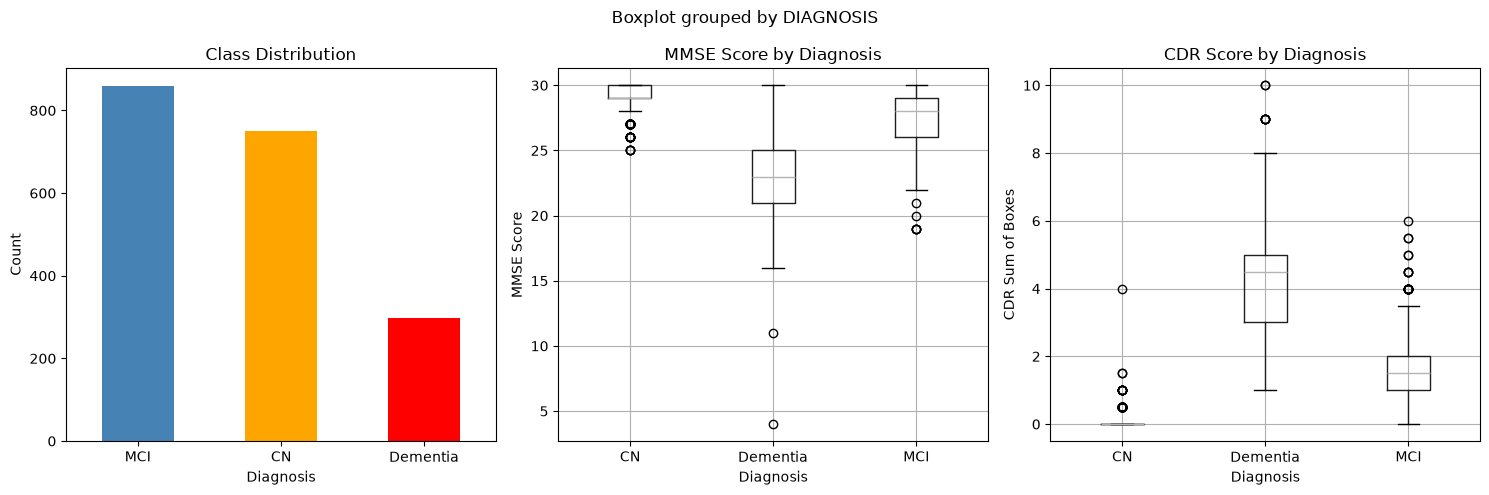

Figure saved to outputs/figures/


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Class distribution
master['DIAGNOSIS'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'orange', 'red'])
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2: MMSE by diagnosis
master.boxplot(column='MMSCORE', by='DIAGNOSIS', ax=axes[1])
axes[1].set_title('MMSE Score by Diagnosis')
axes[1].set_xlabel('Diagnosis')
axes[1].set_ylabel('MMSE Score')

# Plot 3: CDR by diagnosis
master.boxplot(column='CDRSB', by='DIAGNOSIS', ax=axes[2])
axes[2].set_title('CDR Score by Diagnosis')
axes[2].set_xlabel('Diagnosis')
axes[2].set_ylabel('CDR Sum of Boxes')

plt.tight_layout()
plt.savefig('../outputs/figures/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to outputs/figures/")

In [30]:
import os

mri_root = r'C:\Users\arine\Downloads\ADNI1_Complete_1Yr_1.5T'

folders = os.listdir(mri_root)
print(f"Total folders: {len(folders)}")
print("\nFirst 5 folders:")
for f in folders[:5]:
    print(f)

adni_root = r'C:\Users\arine\Downloads\ADNI1_Complete_1Yr_1.5T\ADNI'

# Find all .nii files recursively
nii_files = []
for root, dirs, files in os.walk(adni_root):
    for file in files:
        if file.endswith('.nii') or file.endswith('.nii.gz'):
            nii_files.append(os.path.join(root, file))

print(f"Total NIfTI files found: {len(nii_files)}")
print("\nFirst 3 file paths:")
for f in nii_files[:3]:
    print(f)

Total folders: 1

First 5 folders:
ADNI
Total NIfTI files found: 480

First 3 file paths:
C:\Users\arine\Downloads\ADNI1_Complete_1Yr_1.5T\ADNI\002_S_0295\MPR__GradWarp__B1_Correction__N3__Scaled\2006-04-18_08_20_30.0\I45108\ADNI_002_S_0295_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070319113623975_S13408_I45108.nii
C:\Users\arine\Downloads\ADNI1_Complete_1Yr_1.5T\ADNI\002_S_0413\MPR__GradWarp__B1_Correction__N3__Scaled\2006-05-02_12_31_52.0\I45117\ADNI_002_S_0413_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070319115331858_S13893_I45117.nii
C:\Users\arine\Downloads\ADNI1_Complete_1Yr_1.5T\ADNI\002_S_0619\MPR-R__GradWarp__N3__Scaled\2006-06-01_20_04_45.0\I48617\ADNI_002_S_0619_MR_MPR-R__GradWarp__N3__Scaled_Br_20070411125458928_S15145_I48617.nii


In [31]:
import re

# Extract subject ID from each file path
def extract_subject_id(filepath):
    # Subject ID pattern: three digits, underscore, S, underscore, four digits
    match = re.search(r'\d{3}_S_\d{4}', filepath)
    if match:
        return match.group()
    return None

# Build a dataframe of filepath + subject ID
mri_df = pd.DataFrame({'filepath': nii_files})
mri_df['PTID'] = mri_df['filepath'].apply(extract_subject_id)

print(f"Total MRI files: {len(mri_df)}")
print(f"Unique subjects: {mri_df['PTID'].nunique()}")
print(f"Missing subject IDs: {mri_df['PTID'].isnull().sum()}")
print("\nSample:")
print(mri_df.head(3))

Total MRI files: 480
Unique subjects: 465
Missing subject IDs: 0

Sample:
                                            filepath        PTID
0  C:\Users\arine\Downloads\ADNI1_Complete_1Yr_1....  002_S_0295
1  C:\Users\arine\Downloads\ADNI1_Complete_1Yr_1....  002_S_0413
2  C:\Users\arine\Downloads\ADNI1_Complete_1Yr_1....  002_S_0619


In [32]:
# Merge MRI filepaths into master table
master_with_mri = master.merge(mri_df, on='PTID', how='inner')

print(f"Subjects with both MRI and clinical data: {len(master_with_mri)}")
print("\nClass distribution of matched subjects:")
print(master_with_mri['DIAGNOSIS'].value_counts())
print("\nMissing values in key columns:")
print(master_with_mri[['DIAGNOSIS', 'label', 'filepath', 'MMSCORE', 'CDRSB']].isnull().sum())

Subjects with both MRI and clinical data: 480

Class distribution of matched subjects:
DIAGNOSIS
MCI         181
CN          150
Dementia    149
Name: count, dtype: int64

Missing values in key columns:
DIAGNOSIS    0
label        0
filepath     0
MMSCORE      0
CDRSB        0
dtype: int64


In [33]:
# Save master CSV
output_path = '../data/processed/master_labels.csv'
master_with_mri.to_csv(output_path, index=False)

print(f"Master CSV saved to {output_path}")
print(f"Shape: {master_with_mri.shape}")
print(f"\nColumns: {master_with_mri.columns.tolist()}")

Master CSV saved to ../data/processed/master_labels.csv
Shape: (480, 50)

Columns: ['ORIGPROT', 'COLPROT', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'DIAGNOSIS', 'DXNORM', 'DXNODEP', 'DXMCI', 'DXMDES', 'DXMPTR1', 'DXMPTR2', 'DXMPTR3', 'DXMPTR4', 'DXMPTR5', 'DXMPTR6', 'DXMDUE', 'DXMOTHET', 'DXDSEV', 'DXDDUE', 'DXAD', 'DXAPP', 'DXAPROB', 'DXAPOSS', 'DXPARK', 'DXPDES', 'DXPCOG', 'DXPATYP', 'DXDEP', 'DXOTHDEM', 'DXODES', 'DXCONFID', 'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'DD_CRF_VERSION_LABEL', 'LANGUAGE_CODE', 'HAS_QC_ERROR', 'update_stamp', 'label', 'PTGENDER', 'PTEDUCAT', 'PTETHCAT', 'PTRACCAT', 'MMSCORE', 'CDRSB', 'filepath']


In [37]:
# Keep only relevant columns
cols_to_keep = [
    'PTID',          # subject ID
    'DIAGNOSIS',     # text label
    'label',         # numeric label (0/1/2)
    'VISCODE',       # visit code
    'EXAMDATE',      # scan date
    'PTGENDER',      # sex
    'PTEDUCAT',      # years of education
    'PTETHCAT',      # ethnicity
    'PTRACCAT',      # race
    'MMSCORE',       # MMSE cognitive score
    'CDRSB',         # CDR sum of boxes
    'filepath'       # path to NIfTI file
]

master_final = master_with_mri[cols_to_keep].copy()

# Check for duplicate PTIDs
print("Rows before dedup:", len(master_with_mri))
print("Unique PTIDs:", master_with_mri['PTID'].nunique())

# Deduplicate
master_final = master_with_mri.drop_duplicates(subset='PTID', keep='first')
master_final = master_final[cols_to_keep].copy()

print("Rows after dedup:", len(master_final))
print("\nClass distribution:")
print(master_final['DIAGNOSIS'].value_counts())

# Overwrite the CSV
master_final.to_csv('../data/processed/master_labels.csv', index=False)
print("\nMaster CSV saved")

Rows before dedup: 480
Unique PTIDs: 465
Rows after dedup: 465

Class distribution:
DIAGNOSIS
MCI         181
CN          150
Dementia    134
Name: count, dtype: int64

Master CSV saved


In [38]:
import nibabel as nib

# Test loading first 3 files
for i, row in master_final.head(3).iterrows():
    img = nib.load(row['filepath'])
    data = img.get_fdata()
    print(f"Subject: {row['PTID']} | Diagnosis: {row['DIAGNOSIS']} | Shape: {data.shape} | Voxel size: {img.header.get_zooms()}")

Subject: 011_S_0003 | Diagnosis: Dementia | Shape: (192, 192, 160) | Voxel size: (np.float32(1.2451338), np.float32(1.25717), np.float32(1.2013416))
Subject: 011_S_0005 | Diagnosis: CN | Shape: (192, 192, 160) | Voxel size: (np.float32(1.245255), np.float32(1.2572638), np.float32(1.2013872))
Subject: 100_S_0015 | Diagnosis: CN | Shape: (256, 256, 170) | Voxel size: (np.float32(0.9461747), np.float32(0.9400847), np.float32(1.2047477))


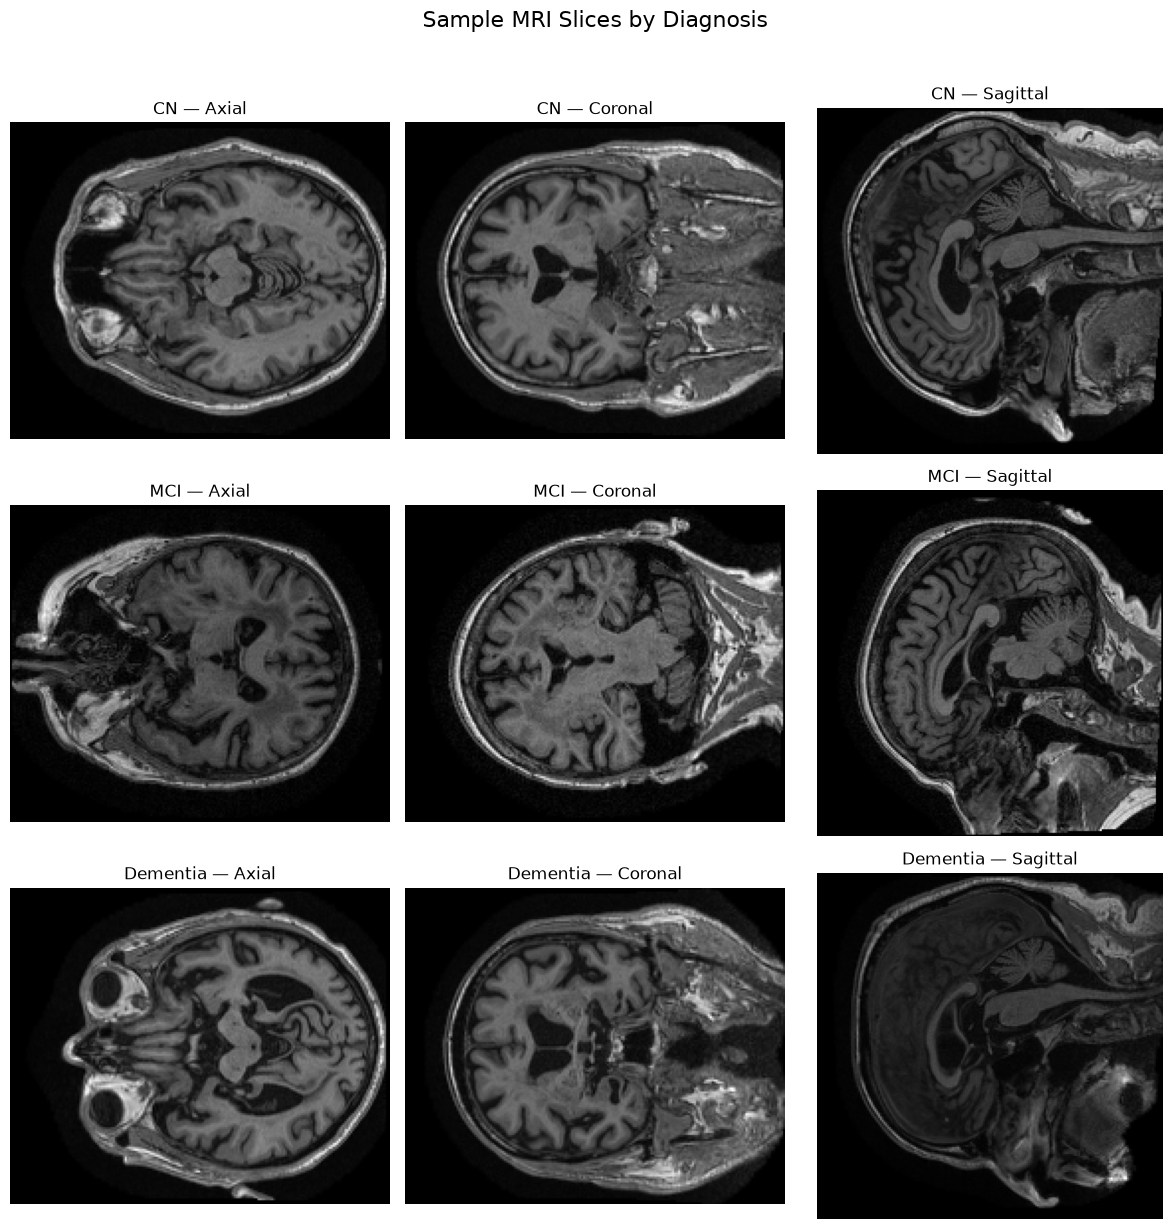

Figure saved


In [39]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
diagnoses = ['CN', 'MCI', 'Dementia']

for row_idx, diagnosis in enumerate(diagnoses):
    # Get one subject per diagnosis
    subject = master_final[master_final['DIAGNOSIS'] == diagnosis].iloc[0]
    img = nib.load(subject['filepath'])
    data = img.get_fdata()
    
    # Get middle slices for each plane
    ax_slice = data[data.shape[0]//2, :, :]
    cor_slice = data[:, data.shape[1]//2, :]
    sag_slice = data[:, :, data.shape[2]//2]
    
    axes[row_idx, 0].imshow(ax_slice.T, cmap='gray', origin='lower')
    axes[row_idx, 0].set_title(f'{diagnosis} — Axial')
    axes[row_idx, 0].axis('off')
    
    axes[row_idx, 1].imshow(cor_slice.T, cmap='gray', origin='lower')
    axes[row_idx, 1].set_title(f'{diagnosis} — Coronal')
    axes[row_idx, 1].axis('off')
    
    axes[row_idx, 2].imshow(sag_slice.T, cmap='gray', origin='lower')
    axes[row_idx, 2].set_title(f'{diagnosis} — Sagittal')
    axes[row_idx, 2].axis('off')

plt.suptitle('Sample MRI Slices by Diagnosis', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/sample_mri_slices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved")